In [1]:
data = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

In [ ]:
# !wget $data

--2026-10-04 06:57:21--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: 'car_fuel_efficiency_2026.csv'

     0K .......... .......... .......... .......... ..........  8% 1.87M 0s
    50K .......... .......... .......... .......... .......... 16% 2.45M 0s
   100K .......... .......... .......... .......... .......... 24% 4.80M 0s
   150K .......... .......... .......... .......... .......... 32% 2.29M 0s
   200K .......... .......... .......... .......... .......... 40% 2.21M 0s
   250K .......... .......... .......... .......... .......... 48% 2.16M 0s
   300K .......... .......... .......... ..

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [7]:
columns = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]

In [8]:
df = df[columns]

In [9]:
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


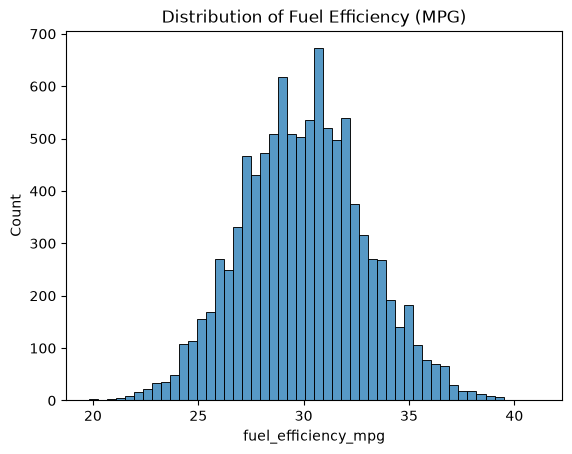

In [10]:
sns.histplot(df['fuel_efficiency_mpg'], bins=50)
plt.title('Distribution of Fuel Efficiency (MPG)')
plt.show()

In [12]:
missing_values = df.isnull().sum()
missing_values

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [13]:
horsepower_median = df['horsepower'].median()
horsepower_median

np.float64(254.0)

In [14]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [15]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [16]:
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

In [17]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [19]:
# filling with 0
X_train_0 = df_train.fillna(0).values
X_val_0 = df_val.fillna(0).values

In [20]:
w_0_0, w_0 = train_linear_regression(X_train_0, y_train)
y_pred_0 = w_0_0 + X_val_0.dot(w_0)
rmse_0 = round(rmse(y_val, y_pred_0), 3)

In [23]:
# filling with mean
mean_val = df_train['horsepower'].mean()
X_train_mean = df_train.fillna(mean_val).values
X_val_mean = df_val.fillna(mean_val).values

In [24]:
w_0_mean, w_mean = train_linear_regression(X_train_mean, y_train)
y_pred_mean = w_0_mean + X_val_mean.dot(w_mean)
rmse_mean = round(rmse(y_val, y_pred_mean), 3)

In [25]:
print(f"RMSE with 0: {rmse_0}")
print(f"RMSE with mean: {rmse_mean}")

RMSE with 0: 2.205
RMSE with mean: 2.202


In [26]:
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
best_rmse = float('inf')
best_r = None

for r in r_values:
    w_0, w = train_linear_regression_reg(X_train_0, y_train, r=r)
    y_pred = w_0 + X_val_0.dot(w)
    score = round(rmse(y_val, y_pred), 4)
    
    print(f"r={r:<5} | RMSE={score}")
    
    if score < best_rmse:
        best_rmse = score
        best_r = r

print(f"\nBest r: {best_r} with RMSE: {best_rmse}")

r=0     | RMSE=2.2053
r=0.01  | RMSE=2.2058
r=0.1   | RMSE=2.2241
r=1     | RMSE=2.3492
r=5     | RMSE=2.4094
r=10    | RMSE=2.4195
r=100   | RMSE=2.4292

Best r: 0 with RMSE: 2.2053


In [27]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmses = []

for s in seeds:
    np.random.seed(s)
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_train_s = df.iloc[idx[:n_train]].copy()
    df_val_s = df.iloc[idx[n_train:n_train + n_val]].copy()
    
    y_train_s = df_train_s['fuel_efficiency_mpg'].values
    y_val_s = df_val_s['fuel_efficiency_mpg'].values
    
    del df_train_s['fuel_efficiency_mpg']
    del df_val_s['fuel_efficiency_mpg']
    
    # Fill NAs with 0
    X_train_s = df_train_s.fillna(0).values
    X_val_s = df_val_s.fillna(0).values
    
    # Train without regularization
    w_0, w = train_linear_regression(X_train_s, y_train_s)
    y_pred_s = w_0 + X_val_s.dot(w)
    
    score = rmse(y_val_s, y_pred_s)
    rmses.append(score)

std_rmse = round(np.std(rmses), 3)
print(f"Standard deviation of all scores: {std_rmse}")

Standard deviation of all scores: 0.029


In [28]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train_f = df.iloc[idx[:n_train]].copy()
df_val_f = df.iloc[idx[n_train:n_train + n_val]].copy()
df_test_f = df.iloc[idx[n_train + n_val:]].copy()

y_train_f = df_train_f['fuel_efficiency_mpg'].values
y_val_f = df_val_f['fuel_efficiency_mpg'].values
y_test_f = df_test_f['fuel_efficiency_mpg'].values

del df_train_f['fuel_efficiency_mpg']
del df_val_f['fuel_efficiency_mpg']
del df_test_f['fuel_efficiency_mpg']

df_full_train = pd.concat([df_train_f, df_val_f]).reset_index(drop=True)
X_full_train = df_full_train.fillna(0).values
y_full_train = np.concatenate([y_train_f, y_val_f])

X_test_f = df_test_f.fillna(0).values

w_0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

y_pred_f = w_0 + X_test_f.dot(w)
test_rmse = round(rmse(y_test_f, y_pred_f), 3) 

print(f"RMSE on the test dataset: {test_rmse}")

RMSE on the test dataset: 2.236
